# Lazy Browse — DestinE Climate DT Portfolio

This notebook provides an **instant xarray view** of DestinE Climate DT Generation 2 data.
Variables and coordinates appear immediately, actual data is fetched from the data bridge **only when you access values** (e.g. plotting, `.values`, `.compute()`).

**Prerequisites:** run `01_key_destine_once.ipynb` once to authenticate.

In [1]:
import logging, warnings
import earthkit.data

# Disable earthkit disk cache (polytope_zarr caches decoded arrays in memory)
earthkit.data.config.set("cache-policy", "off")

# Silence verbose output from polytope / earthkit internals
for _ln in ("polytope", "polytope.api", "earthkit.data", "urllib3"):
    logging.getLogger(_ln).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
import numpy as np
import pandas as pd
from polytope_zarr import PolytopeZarrStore
from destine_portfolio import PORTFOLIO_GEN2_CLMN

## 1. Define the dataset

We declare which coordinates, variables, and Polytope request fields to use.
Nothing is downloaded here — the store just builds metadata.

In [3]:
# ── Configuration ──────────────────────────────────────────────────
MODELS       = ["ICON", "IFS-FESOM", "IFS-NEMO"]
EXPERIMENT   = "hist"              # 'hist', 'SSP3-7.0'
YEARS        = range(1990, 2015)   # 25-year historical period

# ── Choose a levtype (uncomment one) ──────────────────────────────
LEVTYPE = "sfc"                    # 34 vars — surface atmosphere
# LEVTYPE = "pl"                   #  9 vars — pressure levels (19 levels, 1000–1 hPa)
# LEVTYPE = "hl"                   #  2 vars — height levels (100 m, IFS-only)
# LEVTYPE = "sol"                  #  2 vars — soil / snow (5 levels)
# LEVTYPE = "o2d"                  # 13 vars — 2-D ocean & sea ice
# LEVTYPE = "o3d"                  #  5 vars — 3-D ocean (up to 75 levels)

store = PolytopeZarrStore.from_climate_dt(
    models=MODELS,
    experiment=EXPERIMENT,
    levtype=LEVTYPE,
    years=YEARS,
)
print(store)

<PolytopeZarrStore 34 variables (time=300, cell=196608, model=3)>


## 2. Open as xarray Dataset

This is **instant** — no data downloaded yet. You see all variables,
dimensions, and coordinate values.

In [4]:
ds = store.open()
ds

<xarray.Dataset> Size: 24GB
Dimensions:       (model: 3, time: 300, cell: 196608)
Coordinates:
  * model         (model) object 24B 'ICON' 'IFS-FESOM' 'IFS-NEMO'
  * time          (time) datetime64[ns] 2kB 1990-01-01 1990-02-01 ... 2014-12-01
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    avg_10u       (model, time, cell) float32 708MB ...
    avg_10v       (model, time, cell) float32 708MB ...
    avg_10ws      (model, time, cell) float32 708MB ...
    avg_2d        (model, time, cell) float32 708MB ...
    avg_2t        (model, time, cell) float32 708MB ...
    avg_ie        (model, time, cell) float32 708MB ...
    ...            ...
    avg_tnlwrf    (model, time, cell) float32 708MB ...
    avg_tnlwrfcs  (model, time, cell) float32 708MB ...
    avg_tnswrf    (model, time, cell) float32 708MB ...
    avg_tnswrfcs  (model, time, cell) float32 708MB ...
    avg_tprate    (model, time, cell) float32 708MB ...
    avg_tsrwe     (model, time, cell) float32 708MB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=300, cell=196608,...

## 3. Plot a single monthly field (triggers lazy fetch)

Only now does the store actually call Polytope — fetching data for the
selected model, time, and variable.

2026-05-07 17:16:36 - INFO - Key read from /Users/natr/.polytopeapirc
2026-05-07 17:16:36 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'month: 1/2/3/4/5/6/7/8/9/10/11/12\n'
            'param: avg_2t\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clmn\n'
            'type: fc\n'
            "year: '2010'\n",
 'verb': 'retrieve'}
2026-05-07 17:16:36 - INFO - Polytope user key found in session cache for user natr


Fetching {'cell': 196608} values...
  ⚡ batching 12 time chunks for avg_2t


2026-05-07 17:16:37 - INFO - Request accepted. Please poll ./96133669-b21c-4e82-bb39-f9d14599c8c0 for status
2026-05-07 17:16:37 - INFO - Polytope user key found in session cache for user natr
2026-05-07 17:16:37 - INFO - Checking request status (96133669-b21c-4e82-bb39-f9d14599c8c0)...
2026-05-07 17:16:38 - INFO - The current status of the request is 'queued'
2026-05-07 17:16:38 - INFO - The current status of the request is 'processing'
2026-05-07 17:16:42 - INFO - The current status of the request is 'processed'


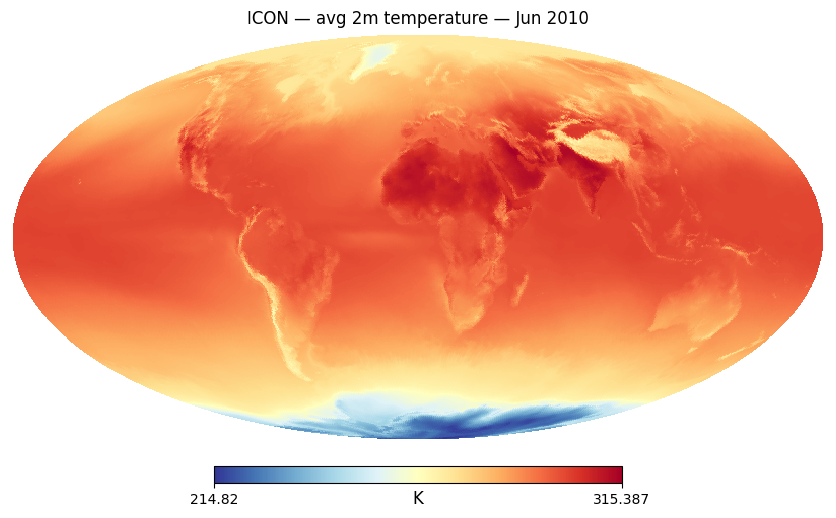

In [5]:
import healpy as hp
import matplotlib.pyplot as plt

field = ds["avg_2t"].sel(model="IFS-FESOM", time="2010-06-01")
print(f"Fetching {dict(field.sizes)} values...")  # triggers the Polytope request

hp.mollview(field.values, title="ICON — avg 2m temperature — Jun 2010",
            unit="K", cmap="RdYlBu_r", nest=True, flip='geo')
plt.show()

  ⚡ batching 12 time chunks for avg_tprate


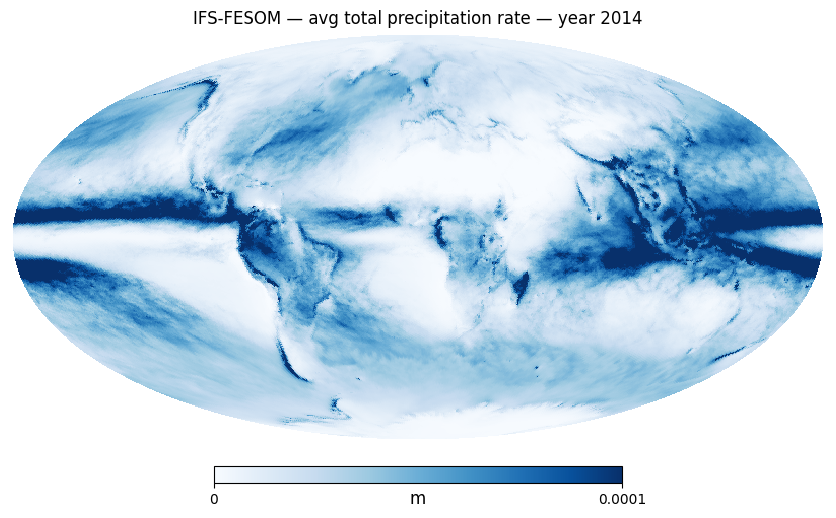

In [6]:
#annual mean
field2 = ds["avg_tprate"].sel(model="IFS-FESOM", time=slice("2014-01", "2014-12")).mean("time")

hp.mollview(field2.values,
            title="IFS-FESOM — avg total precipitation rate — year 2014",
            unit="m", cmap="Blues", min=0, max=0.0001, nest=True, flip='geo')
plt.show()

## 4. Compare experiments: climate change signal

Create a second store for the scenario experiment, then take the difference to the historical.
`.polytope.sel()` automatically sets `batch_years` from the time slice so each call fetches all requested years in one Polytope request.

> **Note:** ICON scenario data is available to **2040**; IFS-NEMO/IFS-FESOM to **2049**.
> When slicing ICON scenario data, use `time=slice("2015-01", "2040-12")`.

In [7]:
SCEN_EXPERIMENT = "SSP3-7.0"
SCEN_YEARS      = range(2015, 2050)

scen_store = PolytopeZarrStore.from_climate_dt(
    models=MODELS,
    experiment=SCEN_EXPERIMENT,
    levtype=LEVTYPE,
    years=SCEN_YEARS,
)

ds_scen = scen_store.open()
ds_scen

<xarray.Dataset> Size: 34GB
Dimensions:       (model: 3, time: 420, cell: 196608)
Coordinates:
  * model         (model) object 24B 'ICON' 'IFS-FESOM' 'IFS-NEMO'
  * time          (time) datetime64[ns] 3kB 2015-01-01 2015-02-01 ... 2049-12-01
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    avg_10u       (model, time, cell) float32 991MB ...
    avg_10v       (model, time, cell) float32 991MB ...
    avg_10ws      (model, time, cell) float32 991MB ...
    avg_2d        (model, time, cell) float32 991MB ...
    avg_2t        (model, time, cell) float32 991MB ...
    avg_ie        (model, time, cell) float32 991MB ...
    ...            ...
    avg_tnlwrf    (model, time, cell) float32 991MB ...
    avg_tnlwrfcs  (model, time, cell) float32 991MB ...
    avg_tnswrf    (model, time, cell) float32 991MB ...
    avg_tnswrfcs  (model, time, cell) float32 991MB ...
    avg_tprate    (model, time, cell) float32 991MB ...
    avg_tsrwe     (model, time, cell) float32 991MB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=420, cell=196608,...

  ⚡ batching 420 time chunks across 35 years for avg_2t


  ⚡ batching 288 time chunks across 24 years for avg_2t


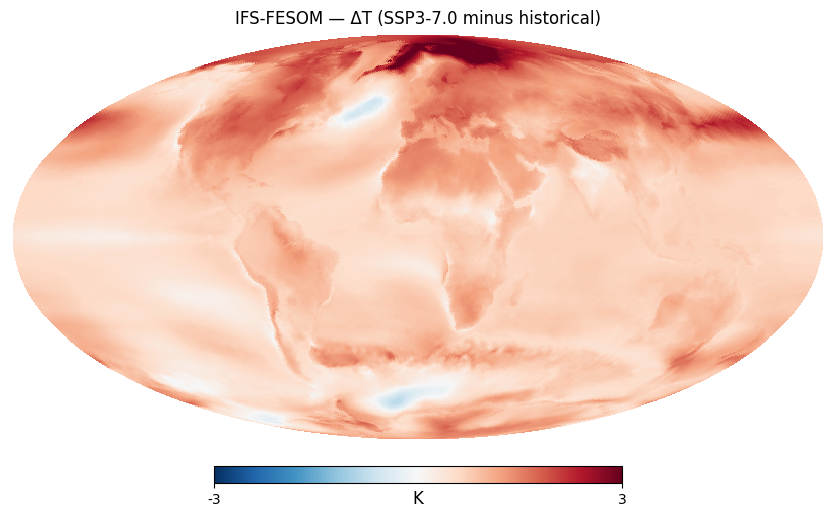

In [8]:
# .polytope.sel() auto-sets the number of batched years from the time slice -> single request per period, instead of ~30 requests per period
hist_field = ds["avg_2t"].polytope.sel(model="IFS-FESOM", time=slice("1990-01", "2014-12"))
scen_field = ds_scen["avg_2t"].polytope.sel(model="IFS-FESOM", time=slice("2015-01", "2049-12"))

diff = scen_field.mean("time") - hist_field.mean("time")

hp.mollview(diff,
            title="IFS-FESOM — ΔT (SSP3-7.0 minus historical)",
            unit="K", cmap="RdBu_r", min=-3, max=3, nest=True, flip='geo')
plt.show()

## Server-side spatial subsetting (Polytope features)

`.polytope.sel()` also supports **server-side spatial extraction** via the
Polytope feature API.  Pass `bbox`, `polygon`, or `point` to get data on a
regular lat/lon grid instead of HEALPix cells.

In [9]:
# Bounding box over Central Europe — single date, returns lat/lon grid
bbox_ds = ds["avg_2t"].polytope.sel(
    model="IFS-FESOM",
    time="2010-06",
    bbox=(47, 5, 55, 15),   # (south, west, north, east)
)
bbox_ds

  🌍 boundingbox request for avg_2t (2010-6)


<xarray.Dataset> Size: 9kB
Dimensions:    (time: 1, points: 235)
Coordinates:
  * time       (time) datetime64[ns] 8B 2010-06-01
  * points     (points) int64 2kB 0 1 2 3 4 5 6 ... 228 229 230 231 232 233 234
    latitude   (points) float64 2kB 47.36 47.36 47.36 ... 54.72 54.72 54.72
    longitude  (points) float64 2kB 13.82 13.03 7.5 6.711 ... 5.211 7.105 14.68
    levelist   (points) float64 2kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    avg_2t     (time, points) float64 2kB 282.7 282.0 288.3 ... 284.7 284.4
Attributes: (12/16)
    activity:       baseline
    class:          d1
    dataset:        climate-dt
    experiment:     hist
    expver:         0001
    generation:     2
    ...             ...
    stream:         clmn
    type:           fc
    number:         0
    Forecast date:  2010-06-01T00:00:00Z
    step:           0
    date:           2010-06-01T00:00:00Z

In [10]:
# Timeseries at a single point (Berlin) over one year
ts_ds = ds["avg_2t"].polytope.sel(
    model="IFS-FESOM",
    time=slice("2010-01", "2010-12"),
    point=(52.5, 13.4),  # (lat, lon) — Berlin
)
ts_ds

  🌍 timeseries request for avg_2t (2010-1/2/3/4/5/6/7/8/9/10/11/12)


{'type': 'CoverageCollection',
 'domainType': 'PointSeries',
 'coverages': [{'mars:metadata': {'activity': 'baseline',
    'class': 'd1',
    'dataset': 'climate-dt',
    'experiment': 'hist',
    'expver': '0001',
    'generation': '2',
    'levtype': 'sfc',
    'model': 'ifs-fesom',
    'realization': 1,
    'resolution': 'standard',
    'stream': 'clmn',
    'type': 'fc',
    'number': 0,
    'levelist': 0},
   'type': 'Coverage',
   'domain': {'type': 'Domain',
    'axes': {'latitude': {'values': [52.416011889394]},
     'longitude': {'values': [13.811881188119]},
     'levelist': {'values': [0]},
     't': {'values': ['2010-01-01T00:00:00Z',
       '2010-02-01T00:00:00Z',
       '2010-03-01T00:00:00Z',
       '2010-04-01T00:00:00Z',
       '2010-05-01T00:00:00Z',
       '2010-06-01T00:00:00Z',
       '2010-07-01T00:00:00Z',
       '2010-08-01T00:00:00Z',
       '2010-09-01T00:00:00Z',
       '2010-10-01T00:00:00Z',
       '2010-11-01T00:00:00Z',
       '2010-12-01T00:00:00Z']}}},


## Notes for further use

- **Automatic batching:** use `.polytope.sel(time=slice(...))` to auto-batch Polytope requests over the requested year range. Regular `.sel()` fetches one year at a time (12 months per request).
- Try the other `LEVTYPES` as well in order to browse the full Climate DT portfolio, i.e. `o2d/o3d`, `pl/hl`, or `sol`
- `store.clear_cache()` frees memory from previously fetched fields.

In [11]:
# Free memory if needed
store.clear_cache()
scen_store.clear_cache()